In [1]:
# Set up the file path
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.append(parent_dir)
task_name = 'NLDoseResponse_3s_7r'
print('Working directory set to:', parent_dir)

Working directory set to: /local0/rossin/git/CRN-GenerativeAI


In [2]:
# Import general packages
from openpyxl import Workbook, load_workbook
from openpyxl.utils import get_column_letter
from datetime import datetime
import torch
from matplotlib import pyplot as plt
from pytorch_lightning.loggers import CometLogger
import numpy as np
from itertools import product
from tqdm import tqdm

# Import Agent-Environment packages
from RL4CRN.environments.environment import Environment
from RL4CRN.environments.parallel_environments import ParallelEnvironments
from RL4CRN.environments.serial_environments import SerialEnvironments
from RL4CRN.agents.reinforce_agent import REINFORCEAgent
from RL4CRN.policies.add_reaction_by_ordered_index import AddReactionByOrderedIndex
from RL4CRN.policies.add_reaction_by_index import AddReactionByIndex

# Import Interface packages
from RL4CRN.env2agent_interface.explicit_observer import ExplicitObserver
from RL4CRN.env2agent_interface.explicit_tensorizer import ExplicitTensorizer
from RL4CRN.agent2env_interface.library_actuator import LibraryActuator
from RL4CRN.agent2env_interface.iocrn_stepper import IOCRNStepper

# Import CRN packages
from RL4CRN.iocrns.iocrn import IOCRN
from RL4CRN.iocrns.reactions import MassAction
from RL4CRN.utils.ic import IC
from RL4CRN.iocrns.reaction_library import construct_hill_production_library

# Import Reward packages
from RL4CRN.rewards.deterministic import dynamic_tracking_error
from RL4CRN.rewards.stochastic import dynamic_tracking_error_SSA

In [ ]:
# Set the logger to use Comet
timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
api_key = "vhIR3uyqsKyU4L7SA8fLCfTSC"
logger = CometLogger(
    api_key=api_key,
    project=task_name,        
    workspace="redsnic", 
    name=f'{task_name}_{timestamp}',
)
logger = logger.experiment

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch, sklearn.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.


In [ ]:
# Construct the template CRN
# add dilution and production reactions for all species
productions = []
dilutions = []
n_inputs = 1
species_labels = [f'IN_{i+1}' for i in range(n_inputs)] 
for i,s in enumerate(species_labels):
    productions.append(MassAction(reactant_labels=[], product_labels=[s], input_channels=[f'u_{i+1}'], params=[1.], params_controllability=[True]))
    dilutions.append(MassAction(reactant_labels=[s], product_labels=[], input_channels=[None], params=[1.], params_controllability=[True])) 

n_support = 2
support_labels = [f'X_{i+1}' for i in range(n_support)] 
for i,s in enumerate(support_labels):
    dilutions.append(MassAction(reactant_labels=[s], product_labels=[], input_channels=[None], params=[1.], params_controllability=[True])) 

species_labels += support_labels
# add diluting output
species_labels.append('OUT') # add output species label
dilutions.append(MassAction(reactant_labels=['OUT'], product_labels=[], input_channels=[None], params=[1.0], params_controllability=[True]))
# productions.append(MassAction(reactant_labels=[], product_labels=['OUT'], input_channels=[None], params=[.5], params_controllability=[True]))



crn_template = IOCRN(productions + dilutions, output_labels=['OUT'])
crn_template.compile()
p = crn_template.num_inputs # Number of inputs of the IOCRNs
print("Template CRN:")
print(crn_template)

# Construct the library of possible reactions
library = construct_hill_production_library(species_labels=species_labels, max_product_order=2, max_num_regulators=2)
library.add_reactions(productions+dilutions) # add the production reactions to the library
library.prepare_lookup_tables()

crn_template.set_library_context(library)

M = len(library.reactions) # Number of possible reactions
K = library.get_num_parameters() # Total number of parameters in all the reactions of the library
print("Library of possible reactions:")
print(library)
print("------------------------------------------------")

Template CRN:
Inputs: ['u_1'] 
Species: ['IN_1', 'OUT', 'X_1'] 
Output Species: ['OUT'] 
∅ ----> IN_1;  [MAK(1.0, u_1)]
IN_1 ----> ∅;  [MAK(1.0)]
X_1 ----> ∅;  [MAK(1.0)]
OUT ----> ∅;  [MAK(1.0)]
Library of possible reactions:
Number of reactions: 166
R0: ∅ ----> IN_1;  [HILLProd(b = None, Vm = None,    (Ka, na) = ;    (Kr, nr) = IN_1(None, 1))]
R1: ∅ ----> IN_1;  [HILLProd(b = None, Vm = None,    (Ka, na) = ;    (Kr, nr) = X_1(None, 1))]
R2: ∅ ----> IN_1;  [HILLProd(b = None, Vm = None,    (Ka, na) = ;    (Kr, nr) = OUT(None, 1))]
R3: ∅ ----> IN_1;  [HILLProd(b = None, Vm = None,    (Ka, na) = IN_1(None, 1);    (Kr, nr) = )]
R4: ∅ ----> IN_1;  [HILLProd(b = None, Vm = None,    (Ka, na) = X_1(None, 1);    (Kr, nr) = )]
R5: ∅ ----> IN_1;  [HILLProd(b = None, Vm = None,    (Ka, na) = OUT(None, 1);    (Kr, nr) = )]
R6: ∅ ----> IN_1;  [HILLProd(b = None, Vm = None,    (Ka, na) = ;    (Kr, nr) = IN_1(None, 1), X_1(None, 1))]
R7: ∅ ----> IN_1;  [HILLProd(b = None, Vm = None,    (Ka, na) = ; 

In [ ]:
# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
print(f'Number of CPUs available: {os.cpu_count()}') 

Using device: cuda
Number of CPUs available: 128


In [ ]:
# Flags and filenames
save_flag = True                                                # Save the agent checkpoint
load_flag = False                                               # Load the agent checkpoint 
train_flag = True                                               # Train the agent
save_sheet_flag = True                                          # Save the configuration to an Excel sheet

save_filename = timestamp + '.pth'                              # Filename for saving the agent checkpoint
load_filename = ''                                              # Filename for loading the agent checkpoint
file_name = f"{task_name}.xlsx"             # Filename for saving the Excel sheet

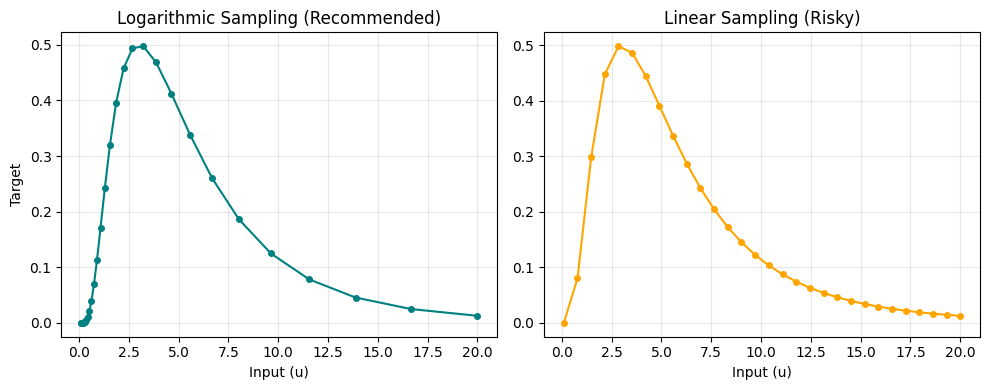

In [ ]:
# %%
from RL4CRN.utils.visualizations import plot_truth_table
import matplotlib.pyplot as plt
import numpy as np
import os

# Hyperparameters (Same as before)
max_added_reactions = 7                             
N_CPUs = os.cpu_count()                                     
N = 10*N_CPUs                                           
width = 1024                                       
depth = 5                                           
deep_layer_size = 1024*10                           
allow_input_influence = False                       
learning_rate = 1e-4                                
hall_of_fame_size = 30                              
entropy_scheduler = {                               
    'entropy_weight': 5e-3, 
    'topk_entropy_weight' : 1.0,
    'remainder_entropy_weight' : 1.0,
    'entropy_update_coefficient': 1, 
    'entropy_schedule': 1000, 
    'minimum_entropy_weight': 0.0
}
entropy_weights_per_head = {'structure': 2.0, 'continuous': 1.0, 'discrete': 0.0, 'input_influence': 0.0} 
structure_head_temperature = {"target_entropy_ratio_to_max": np.log(5)/np.log(M), "initial_temperature": 1.0, "rate": 0.0, "current_temperature": 1.0}
risk_scheduler = {                                  
    'risk': 0.95, 
    'risk_update': 0.0, 
    'max_risk': 1.0, 
    'risk_schedule': 1000
}
epoch_num = 1000                                     
render_schedule = 10                                 
render_mode = {                                     
    'style': 'logger', 
    'task': 'transients + dose-response',
    'format': 'image',
    'topology': True,
    'bounds': [2.5]
}
ordering_parameters = {
    'enforce_ordering': False,
    'constraint_weight' : float('inf')
}
sil_settings = {
    'sil_loss_weight': 1.0,
    'sil_use_adaptive_baseline': False,
    'sil_baseline_annealing_rate': 0.95
}
render_n_best = 10                                                    
render_disregard_percentage = 0.99                                    
continuous_distribution = {"type": 'lognormal_independent'}


# --- Time Horizon Setup ---
t_f = 100                                           
N_t = 1000                                          
time_horizon = np.linspace(0, t_f, N_t, dtype=np.float32)

# --- Define Non-Monotonic Dose-Response Relationship ---

# 1. Inputs (u): Logarithmic sweep to capture the fast rise
n_conditions = 30
# geomspace generates numbers evenly spaced on a log scale
u_values = np.geomspace(0.1, 20.0, n_conditions) 

# Optional: If you strictly need 0.0 as a baseline control
# u_values = np.concatenate(([0.0], u_values))

u_list = [np.array([u]) for u in u_values]

# 2. Target Function (Log-Normal)
optimal_input = 3.0
width_param = 0.7  # Natural width for n=1
max_response = 0.5 

# Calculate targets
scalar_targets = max_response * np.exp(-((np.log(u_values) - np.log(optimal_input))**2) / (2 * width_param**2))

# 3. Construct Reference Trajectories
r_list = [np.array([r]) for r in scalar_targets]

# --- Visualization of Why This Matters ---
plt.figure(figsize=(10, 4))

# Plot 1: The Sampling Distribution
plt.subplot(1, 2, 1)
plt.plot(u_values, scalar_targets, 'o-', color='teal', markersize=4)
plt.title('Logarithmic Sampling (Recommended)')
plt.xlabel('Input (u)')
plt.ylabel('Target')
plt.grid(True, alpha=0.3)
# Note how points are clustered near the peak/start

# Plot 2: Compare to Linear (What you had)
plt.subplot(1, 2, 2)
linear_u = np.linspace(0.1, 20, n_conditions)
linear_target = max_response * np.exp(-((np.log(linear_u) - np.log(optimal_input))**2) / (2 * width_param**2))
plt.plot(linear_u, linear_target, 'o-', color='orange', markersize=4)
plt.title('Linear Sampling (Risky)')
plt.xlabel('Input (u)')
plt.grid(True, alpha=0.3)
# Note the gap at the start!

plt.tight_layout()
plt.show()

# --- Compute Reward Routine ---
# Ensure ic is defined
ic = IC(names=species_labels, values=[[0.0 for _ in species_labels]])

w = np.zeros(N_t)
w[-1] = N_t
w = w[np.newaxis, :]

def compute_reward(state):
    x0_list = ic.get_ic(state)
    # The error is computed over the whole trajectory, but because w is 0 
    # everywhere except the end, the agent is free to do whatever it wants 
    # during the transient phase.
    return dynamic_tracking_error(state, u_list, x0_list, time_horizon, r_list, w, norm=1, LARGE_NUMBER=1e4)

In [ ]:
if save_sheet_flag:
    sheet_name = "Data"
    headers = [
        "Timestamp", "URL",
        "Epochs Completed", "Successful", "Saved", "Comments",
        "Learning Rate", "Epochs #",
        "(m, n, p, N)",
        "NN Depth", "NN Width", "Deep Layer Size", "CPUs #",
        "Entropy Scheduler",
        "Risk Scheduler",
        "Render Schedule", "HoF Size",
        "Simulation Time", "Time Steps #",
        "Initial Conditions #", "Input Scenarios#",
        "Continuous Distribution", "Entropy Weights per Head",
        "Structure Head Temperature",
        "Ordering Enforced",
        "SIL Settings"
    ]

    data_row = [
        timestamp, logger.url,
        None, None, None, None,
        learning_rate, epoch_num,
        str((max_added_reactions, len(species_labels), p, N)),
        depth, width, deep_layer_size, N_CPUs,
        str(entropy_scheduler),
        str(risk_scheduler),
        render_schedule, hall_of_fame_size,
        t_f, N_t, len(ic.values), len(u_list),
        str(continuous_distribution), str(entropy_weights_per_head),
        str(structure_head_temperature),
        f"Yes: {ordering_parameters['constraint_weight']}" if ordering_parameters['enforce_ordering'] else "No",
        str(sil_settings)
    ]

    if os.path.exists(file_name):
        wb = load_workbook(file_name)
        if sheet_name in wb.sheetnames:
            ws = wb[sheet_name]
        else:
            ws = wb.create_sheet(sheet_name)
    else:
        wb = Workbook()
        ws = wb.active
        ws.title = sheet_name

    # Write headers if sheet is empty
    if ws.max_row == 1 and ws.max_column == 1 and ws.cell(row=1, column=1).value is None:
        for col, header in enumerate(headers, start=1):
            ws.cell(row=1, column=col, value=header)

    # Append experiment as next row
    next_row = ws.max_row + 1
    for col, value in enumerate(data_row, start=1):
        ws.cell(row=next_row, column=col, value=value)

    # Freeze header row and add filter
    ws.freeze_panes = "B1" 
    ws.auto_filter.ref = ws.dimensions

    # === Auto-fit column widths (except URL column) ===
    # URL column is column 2 (B), we leave its width unchanged.
    url_col_index = 2

    for col in range(1, ws.max_column + 1):
        if col == url_col_index:
            continue  # keep URL column width as-is

        max_length = 0
        for row in range(1, ws.max_row + 1):
            cell = ws.cell(row=row, column=col)
            value = cell.value
            if value is not None:
                # Convert to string to measure length
                length = len(str(value))
                if length > max_length:
                    max_length = length

        # Some padding so text isn't touching the cell border
        adjusted_width = max_length + 2 if max_length > 0 else 10
        col_letter = get_column_letter(col)
        ws.column_dimensions[col_letter].width = adjusted_width

    wb.save(file_name)
    print(f"New experiment data saved in row {next_row} of '{file_name}'.")

New experiment data saved in row 3 of 'NLDoseResponse_3s_7r.xlsx'.


In [ ]:
# Construct parallel environments
crn_0 = crn_template.clone()
mult_env = ParallelEnvironments([Environment(crn_0, max_added_reactions, logger=logger, logger_schedule=1) for _ in range(N)], hall_of_fame_size=hall_of_fame_size, N_CPUs=N_CPUs, logger=logger)
# mult_env = SerialEnvironments([Environment(crn_0, max_added_reactions, logger=logger, logger_schedule=1) for _ in range(N)], hall_of_fame_size=hall_of_fame_size, logger=logger)

In [ ]:
# Construct the policy
encoder_attributes = {"hidden_size": width, "num_layers": depth}
structure_head_attributes = {"hidden_size": width, "num_layers": depth}
rate_head_attributes = {"hidden_size": width, "num_layers": depth}
input_influence_head_attributes = {"hidden_size": width, "num_layers": depth}
masks = {"continuous": library.get_parameter_mask(mode="continuous"), "discrete": library.get_parameter_mask(mode="discrete"), "logit": library.get_logit_mask()}
policy = AddReactionByOrderedIndex(M, K, p, encoder_attributes, deep_layer_size, structure_head_attributes, rate_head_attributes, input_influence_head_attributes, target_set_size=crn_template.num_reactions+max_added_reactions, allow_input_influence=False, masks=masks, device=device, continuous_distribution=continuous_distribution, entropy_weights_per_head=entropy_weights_per_head,
                                    combinatorial_bias_enabled=ordering_parameters["enforce_ordering"], constraint_strength=ordering_parameters["constraint_weight"])

if ordering_parameters["enforce_ordering"]:
    policy = AddReactionByOrderedIndex(M, K, p, encoder_attributes, deep_layer_size, structure_head_attributes, rate_head_attributes, input_influence_head_attributes, target_set_size=crn_template.num_reactions+max_added_reactions, allow_input_influence=False, masks=masks, device=device, continuous_distribution=continuous_distribution, entropy_weights_per_head=entropy_weights_per_head,
                                        combinatorial_bias_enabled=ordering_parameters["enforce_ordering"], constraint_strength=ordering_parameters["constraint_weight"])
else:
    policy = AddReactionByIndex(M, K, p, encoder_attributes, deep_layer_size, structure_head_attributes, rate_head_attributes, input_influence_head_attributes, allow_input_influence=False, masks=masks, device=device, continuous_distribution=continuous_distribution, entropy_weights_per_head=entropy_weights_per_head)

# Construct the agent
agent = REINFORCEAgent(policy, allow_input_influence=False, logger=logger, learning_rate=learning_rate, entropy_scheduler=entropy_scheduler, risk_scheduler=risk_scheduler, sil_settings=sil_settings, device=device)
if load_flag:
    agent.policy.load_state_dict(torch.load(load_filename+'.pth', map_location=device))

In [ ]:
# Construct the interfaces
observer = ExplicitObserver(reaction_library=library, allow_input_observation=allow_input_influence)
tensorizer = ExplicitTensorizer(device=device)
actuator = LibraryActuator(reaction_library=library)
stepper = IOCRNStepper()

In [ ]:
print(library.reactions[-1].num_parameters)

1


In [ ]:
# Training Loop   
if train_flag:
    agent.policy.train()
    for i in tqdm(range(epoch_num)):
        mult_env.reset()
        for j in range(max_added_reactions):
            observations = mult_env.observe(observer, tensorizer)
            actions, raw_actions = agent.act(observations, actuator)
            out = mult_env.step(actions, stepper, raw_actions=raw_actions)
        rewards = mult_env.get_reward(compute_reward)
        agent.update(rewards, step_iteration=i, hof=mult_env.hall_of_fame, observer=observer, tensorizer=tensorizer, stepper=stepper, use_sil=True, sil_weighting_scheme='uniform', sil_batch_size=None)
        if i % render_schedule == 0:
            mult_env.render(rewards, n_best=render_n_best, disregarded_percentage=render_disregard_percentage, mode=render_mode)

  2%|▏         | 20/1000 [12:51<10:41:33, 39.28s/it]


[cvHandleFailure, Error: -4] At t = 2.22792741090913 and h = 3.36424697534583, the corrector convergence test failed repeatedly or with |h| = hmin.


[cvHandleFailure, Error: -15] At t = 2.31254000947634, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -4] At t = 2.53144862093707 and h = 0.466073816670972, the corrector convergence test failed repeatedly or with |h| = hmin.


[cvHandleFailure, Error: -15] At t = 0.465009614471884, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 1.28575244087624, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 1.307600853748, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 1.26601884975661, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 0.907194643900441, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 0.915054826228385, unable to satisfy inequality constraints.


[cvH

  2%|▏         | 21/1000 [13:40<11:27:00, 42.11s/it]


[cvHandleFailure, Error: -15] At t = 5.06215021377773, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 5.32362006462616, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 3.61555079970594, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 1.63648142947885, unable to satisfy inequality constraints.



  4%|▎         | 35/1000 [23:14<11:07:10, 41.48s/it]

...

100%|█████████▉| 998/1000 [11:13:33<01:18, 39.33s/it]


[cvHandleFailure, Error: -4] At t = 5.12499210079798 and h = 10.4125166105338, the corrector convergence test failed repeatedly or with |h| = hmin.


[cvHandleFailure, Error: -15] At t = 0.876232212281456, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 0.876860173297888, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 0.87630870801785, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 0.876358764193189, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 0.87641881312656, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 0.876490842495855, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 0.876577233553615, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 0.876680839211071, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 0.877402846047

100%|█████████▉| 999/1000 [11:14:20<00:41, 41.61s/it]


[cvHandleFailure, Error: -15] At t = 0.636734051753419, unable to satisfy inequality constraints.



100%|██████████| 1000/1000 [11:14:45<00:00, 40.49s/it]


In [ ]:
hall_of_fame_crns = [env.state for env in mult_env.hall_of_fame]
if save_flag:
    if not os.path.exists('models'):
        os.makedirs('models')
    if not os.path.exists('hof'):
        os.makedirs('hof')
    torch.save(agent.policy.state_dict(), 'models/' + save_filename)
    torch.save(hall_of_fame_crns, 'hof/hall_of_fame_' + save_filename)